# Home Credit Default Risk — Modeling Pipeline

## Pipeline Overview
```
Step 1: Load preprocessed datasets (4 variants)
         ├── traditional_pca
         ├── traditional_no_pca
         ├── combined_pca
         └── combined_no_pca
Step 2: Baseline Models (LR, LightGBM, XGBoost, RandomForest)
Step 3: Evaluation Tables + Plots per dataset variant
         ├── Metrics table (Recall, Precision, F1, Accuracy, AUC)
         ├── AUC Bar Chart across all variants
         ├── ROC Curves
         ├── Precision-Recall Curves
         ├── Confusion Matrices
         ├── Feature Importances (tree models)
         ├── Lift Chart + KS Plot
         └── Cross-Dataset AUC Heatmap
Step 4: Hyperparameter Tuning (RandomizedSearchCV, n_iter=5)
         ├── Best params log
         ├── Baseline vs Tuned AUC comparison
         └── Tuned ROC + AUC heatmap
Step 5: Final evaluation on test set with best tuned models
         ├── Test metrics tables
         ├── Test ROC Curves
         ├── Final AUC heatmap
         └── Overall best model summary
```

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import pipelines.project_config as cfg

sns.set_style('whitegrid')
SEED = 42
DO_HYPERTUNING = False
pd.set_option('display.max_columns', 80)

print('Libraries loaded.')
print(f'Hyperparameter tuning: {"ENABLED" if DO_HYPERTUNING else "DISABLED"}')


Libraries loaded.
Hyperparameter tuning: DISABLED


## 2. Load Datasets

In [2]:
def load_split(directory):
    train = pd.read_csv(f"{directory}/{cfg.PREPROCESSED_FILENAMES['train']}")
    val   = pd.read_csv(f"{directory}/{cfg.PREPROCESSED_FILENAMES['validation']}")
    test  = pd.read_csv(f"{directory}/{cfg.PREPROCESSED_FILENAMES['test']}")
    return train, val, test

def xy(df):
    return df.drop(columns=[cfg.TARGET_COL]), df[cfg.TARGET_COL]

datasets = {
    'traditional_pca':    load_split(cfg.PREPROCESSED_TRADITIONAL_PCA_DIR),
    'traditional_no_pca': load_split(cfg.PREPROCESSED_TRADITIONAL_NO_PCA_DIR),
    'combined_pca':       load_split(cfg.PREPROCESSED_COMBINED_PCA_DIR),
    'combined_no_pca':    load_split(cfg.PREPROCESSED_COMBINED_NO_PCA_DIR),
}

print('Dataset shapes:')
for name, (tr, va, te) in datasets.items():
    print(f'  {name:25s}  train={tr.shape}  val={va.shape}  test={te.shape}')

Dataset shapes:
  traditional_pca            train=(215257, 44)  val=(46127, 44)  test=(46127, 44)
  traditional_no_pca         train=(215257, 65)  val=(46127, 65)  test=(46127, 65)
  combined_pca               train=(215257, 78)  val=(46127, 78)  test=(46127, 78)
  combined_no_pca            train=(215257, 120)  val=(46127, 120)  test=(46127, 120)


In [3]:
# Check for non-numeric columns in the data
print('\nChecking for non-numeric columns:')
for dataset_name, (train_df, val_df, test_df) in datasets.items():
    X_train, y_train = xy(train_df)
    object_cols = X_train.select_dtypes(include='object').columns.tolist()
    if object_cols:
        print(f'\n{dataset_name}:')
        print(f'  Found {len(object_cols)} object columns: {object_cols[:5]}...')
    else:
        print(f'\n{dataset_name}: All columns numeric ✓')



Checking for non-numeric columns:

traditional_pca: All columns numeric ✓

traditional_no_pca: All columns numeric ✓

combined_pca: All columns numeric ✓

combined_no_pca: All columns numeric ✓


## 3. Helper Functions

In [4]:
def evaluate(model, X, y):
    preds = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'Recall':    recall_score(y, preds, zero_division=0),
        'Precision': precision_score(y, preds, zero_division=0),
        'F1':        f1_score(y, preds, zero_division=0),
        'Accuracy':  accuracy_score(y, preds),
        'AUC':       roc_auc_score(y, proba),
    }

def make_base_models(scale_pos_weight=1.0):
    return {
        'LogisticRegression': LogisticRegression(max_iter=2000, random_state=SEED, class_weight='balanced', solver='saga'),
        'LightGBM':           LGBMClassifier(random_state=SEED, verbose=-1, class_weight='balanced', importance_type='gain', n_estimators=500),
        'XGBoost':            XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, scale_pos_weight=scale_pos_weight, tree_method='hist'),
        'RandomForest':       RandomForestClassifier(random_state=SEED, max_depth=10, class_weight='balanced_subsample', n_estimators=100, min_samples_leaf=50),
    }

MODEL_COLORS = {
    'LogisticRegression': '#1976d2',
    'LightGBM':           '#4caf50',
    'XGBoost':            '#ff9800',
    'RandomForest':       '#9c27b0',
}

## 4. Baseline Models — Train & Evaluate

In [5]:
baseline_fitted  = {}
baseline_results = {}
baseline_probas  = {}

for dataset_name, (train_df, val_df, test_df) in datasets.items():
    X_train, y_train = xy(train_df)
    X_val,   y_val   = xy(val_df)
    
    # Calculate scale_pos_weight for XGBoost (ratio of negative to positive samples)
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models = make_base_models(scale_pos_weight=scale_pos_weight)
    rows   = {}
    probas = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        print(f'Fitted {model_name}')
        rows[model_name]   = evaluate(model, X_val, y_val)
        probas[model_name] = model.predict_proba(X_val)[:, 1]

    baseline_fitted[dataset_name]  = models
    baseline_results[dataset_name] = rows
    baseline_probas[dataset_name]  = (probas, y_val)

print('Baseline training complete.')

Fitted LogisticRegression
Fitted LightGBM
Fitted XGBoost
Fitted RandomForest
Fitted LogisticRegression
Fitted LightGBM
Fitted XGBoost
Fitted RandomForest
Fitted LogisticRegression
Fitted LightGBM
Fitted XGBoost
Fitted RandomForest
Fitted LogisticRegression
Fitted LightGBM
Fitted XGBoost
Fitted RandomForest
Baseline training complete.


### 4.1 Baseline Metrics Tables

In [6]:
for dataset_name, rows in baseline_results.items():
    print(f'\n=== {dataset_name} ===')
    df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
    display(df_res.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0).set_caption(dataset_name))


=== traditional_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5222,0.1291,0.2070,0.6809,0.6527
LightGBM,0.3360,0.1500,0.2074,0.7952,0.6464
XGBoost,0.3743,0.1355,0.1989,0.7596,0.6354
RandomForest,0.4229,0.1571,0.2291,0.7730,0.6797



=== traditional_no_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6722,0.1575,0.2552,0.6871,0.7466
LightGBM,0.6067,0.1871,0.2860,0.7584,0.7604
XGBoost,0.6091,0.1799,0.2778,0.7474,0.7502
RandomForest,0.6336,0.1745,0.2737,0.7318,0.7522



=== combined_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5890,0.1412,0.2278,0.6815,0.6892
LightGBM,0.3993,0.1666,0.2351,0.7928,0.6854
XGBoost,0.4148,0.1553,0.2260,0.7734,0.6658
RandomForest,0.4694,0.1682,0.2477,0.7726,0.7073



=== combined_no_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6967,0.1674,0.2699,0.6995,0.7667
LightGBM,0.6023,0.2047,0.3055,0.7816,0.7773
XGBoost,0.6048,0.1931,0.2928,0.7669,0.7648
RandomForest,0.6124,0.1834,0.2822,0.7516,0.7627


### 4.2 Baseline AUC Bar Chart — All Dataset Variants

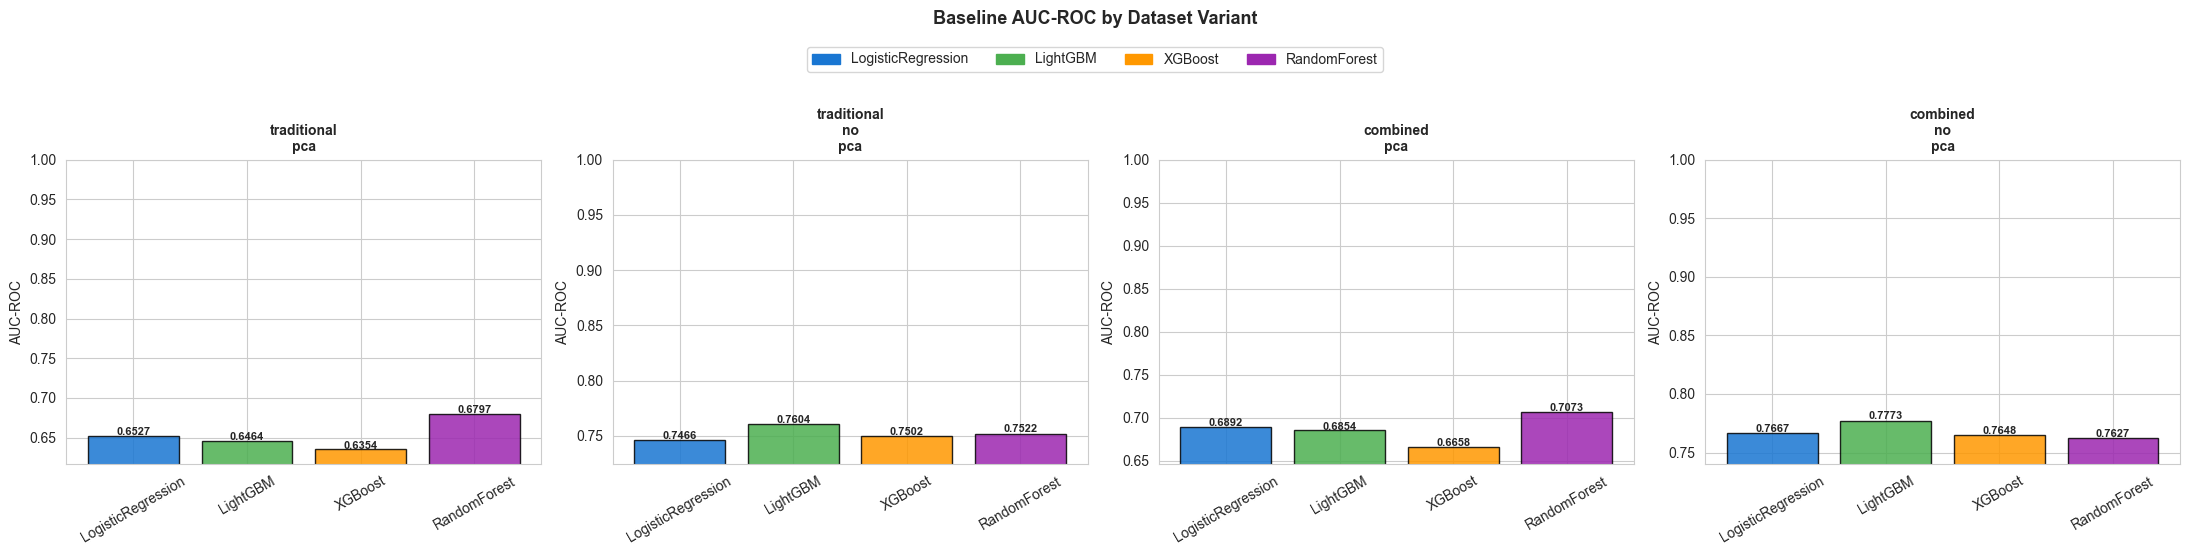

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)

for ax, (dataset_name, rows) in zip(axes, baseline_results.items()):
    model_names = list(rows.keys())
    aucs = [rows[m]['AUC'] for m in model_names]
    colors = [MODEL_COLORS[m] for m in model_names]
    bars = ax.bar(model_names, aucs, color=colors, edgecolor='black', alpha=0.85)
    ax.set_ylim(min(aucs) * 0.97, 1.0)
    ax.set_title(dataset_name.replace('_', '\n'), fontweight='bold', fontsize=10)
    ax.set_ylabel('AUC-ROC')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}',
                ha='center', fontsize=8, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.04))
plt.suptitle('Baseline AUC-ROC by Dataset Variant', fontweight='bold', fontsize=13, y=1.10)
plt.tight_layout()
plt.show()

### 4.3 Cross-Dataset AUC Heatmap

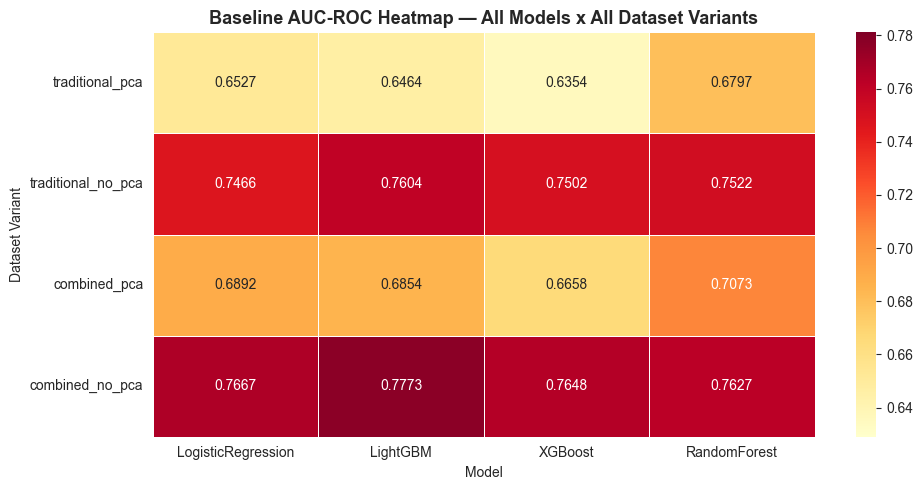

In [8]:
auc_matrix = pd.DataFrame(
    {ds: {m: baseline_results[ds][m]['AUC'] for m in baseline_results[ds]}
     for ds in baseline_results}
).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    auc_matrix.astype(float), annot=True, fmt='.4f',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    vmin=auc_matrix.values.min() * 0.99,
    vmax=auc_matrix.values.max() * 1.005
)
ax.set_title('Baseline AUC-ROC Heatmap — All Models x All Dataset Variants', fontweight='bold', fontsize=13)
ax.set_xlabel('Model')
ax.set_ylabel('Dataset Variant')
plt.tight_layout()
plt.show()

### 4.4 ROC Curves — All Datasets

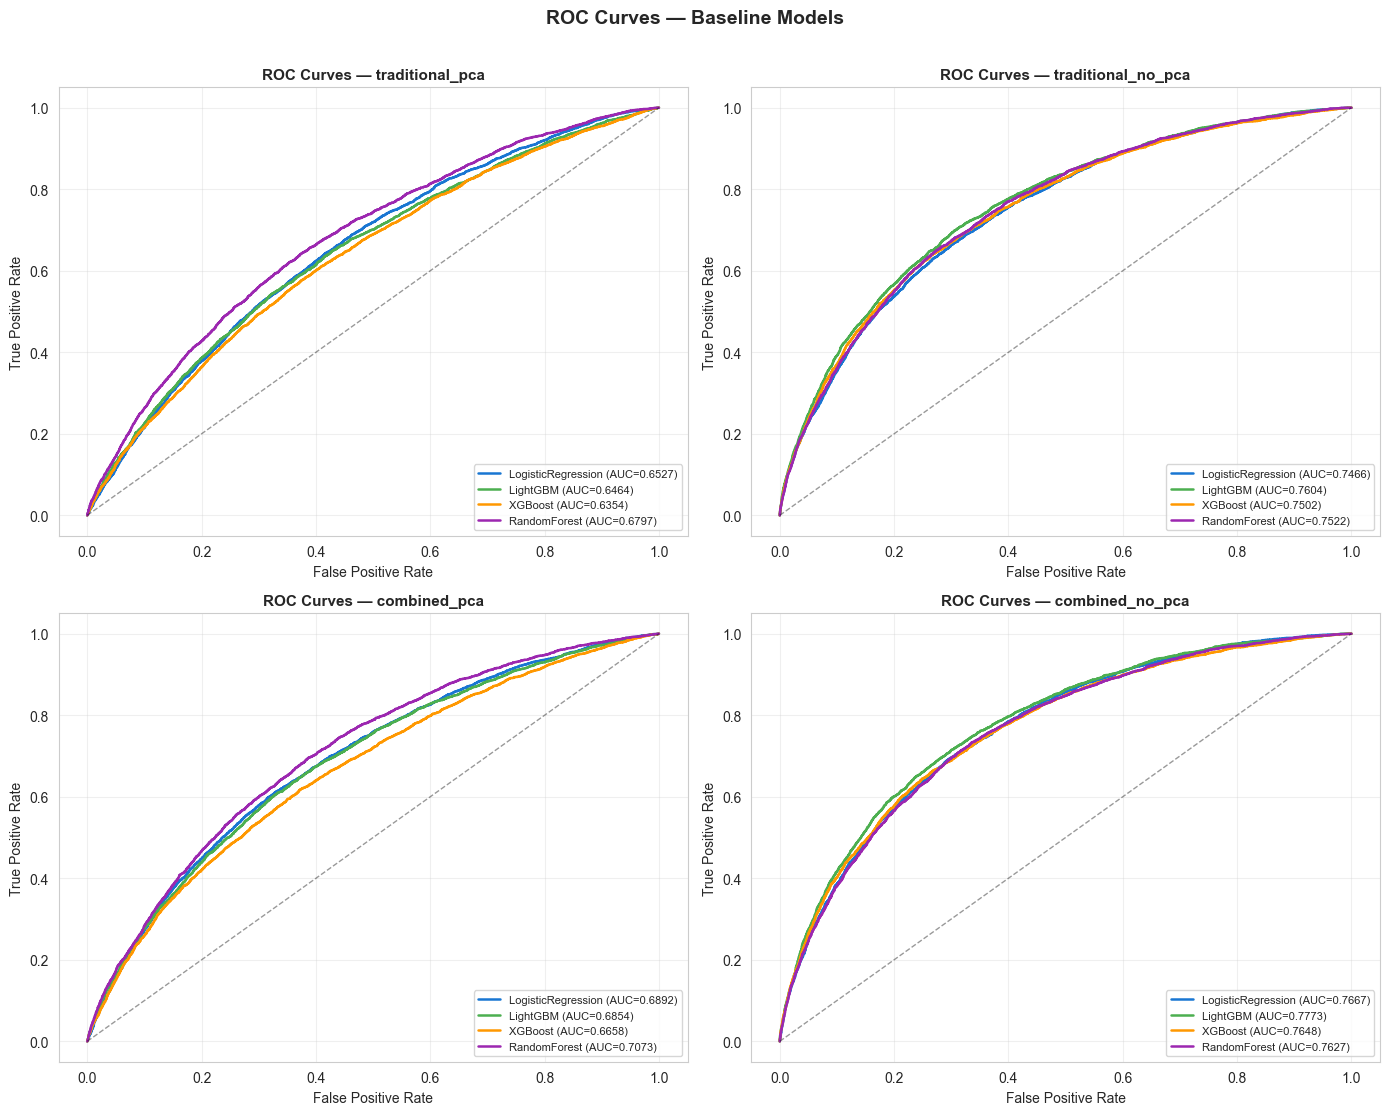

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (dataset_name, (probas, y_val)) in zip(axes.flatten(), baseline_probas.items()):
    for model_name, proba in probas.items():
        fpr, tpr, _ = roc_curve(y_val, proba)
        auc = roc_auc_score(y_val, proba)
        ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=1.8,
                label=f'{model_name} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {dataset_name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Baseline Models', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.5 Precision-Recall Curves — All Datasets

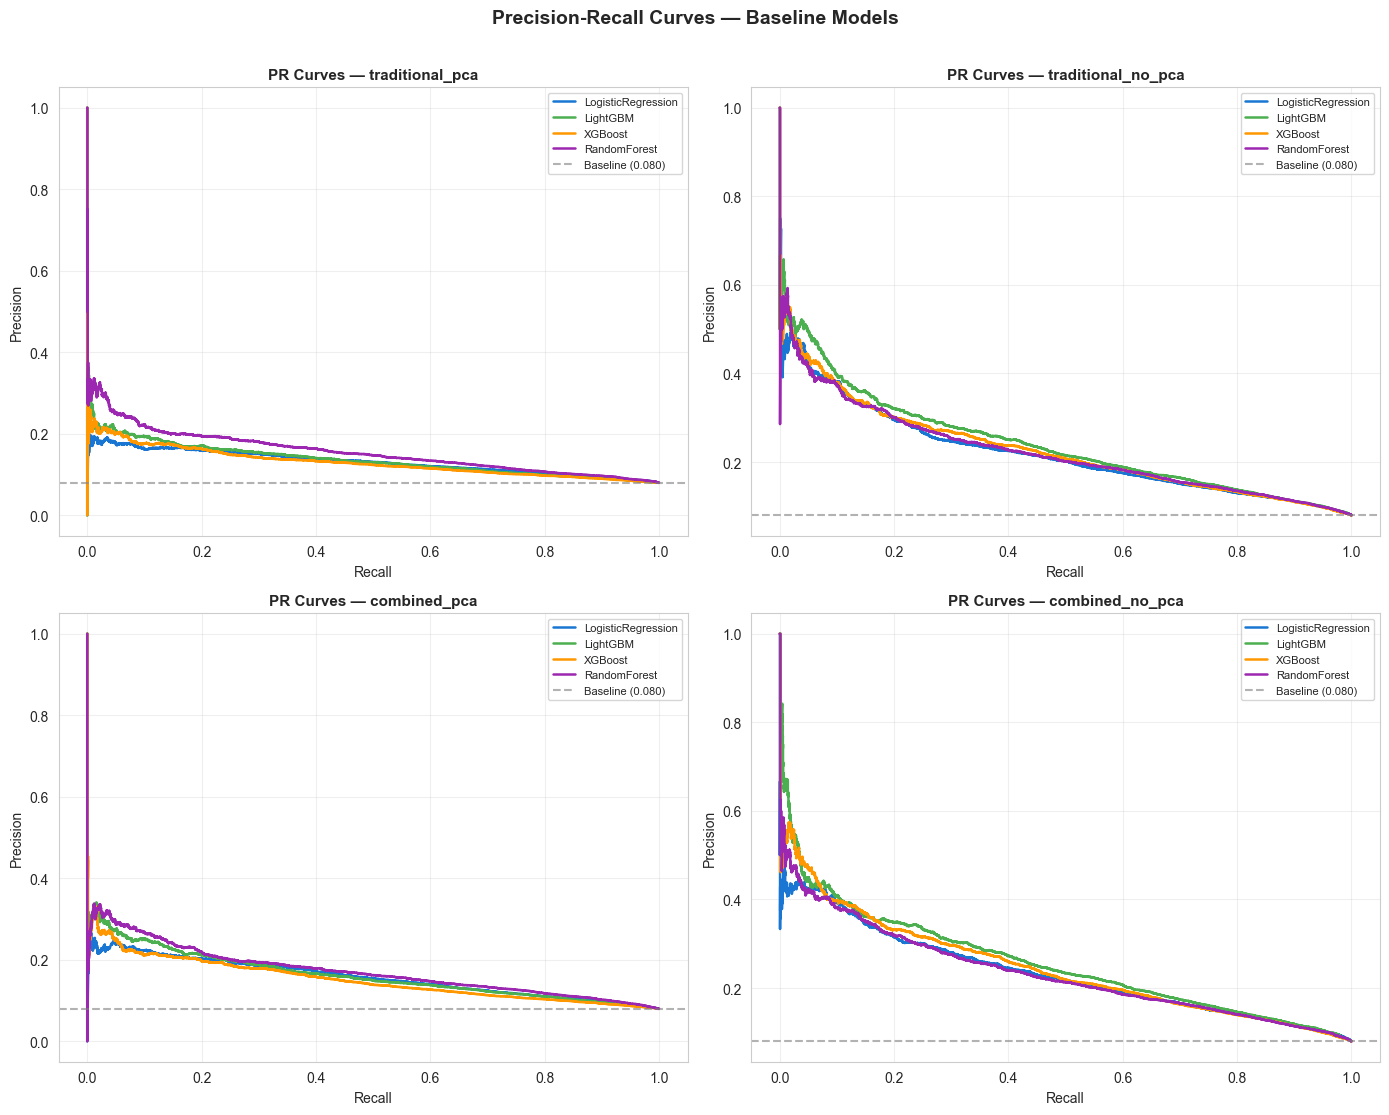

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (dataset_name, (probas, y_val)) in zip(axes.flatten(), baseline_probas.items()):
    baseline_rate = y_val.mean()
    for model_name, proba in probas.items():
        prec, rec, _ = precision_recall_curve(y_val, proba)
        ax.plot(rec, prec, color=MODEL_COLORS[model_name], linewidth=1.8, label=model_name)
    ax.axhline(y=baseline_rate, color='grey', linestyle='--', alpha=0.6,
               label=f'Baseline ({baseline_rate:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — {dataset_name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves — Baseline Models', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.6 Confusion Matrices — Best Performing Dataset

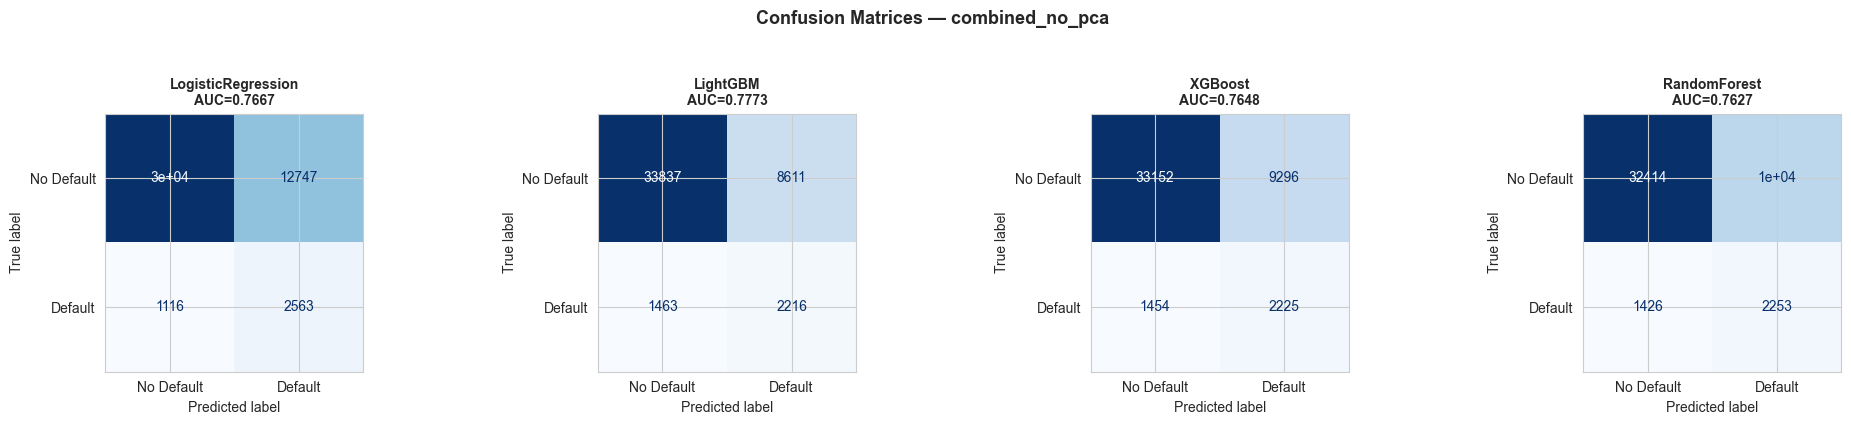

In [11]:
best_dataset = max(
    baseline_results,
    key=lambda d: max(v['AUC'] for v in baseline_results[d].values())
)
_, val_df_best, _ = datasets[best_dataset]
X_val_best, y_val_best = xy(val_df_best)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (model_name, model) in zip(axes, baseline_fitted[best_dataset].items()):
    preds = model.predict(X_val_best)
    cm = confusion_matrix(y_val_best, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = baseline_results[best_dataset][model_name]['AUC']
    ax.set_title(f'{model_name}\nAUC={auc:.4f}', fontweight='bold', fontsize=10)

plt.suptitle(f'Confusion Matrices — {best_dataset}', fontweight='bold', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### 4.7 Feature Importances (Tree Models) — Best Dataset

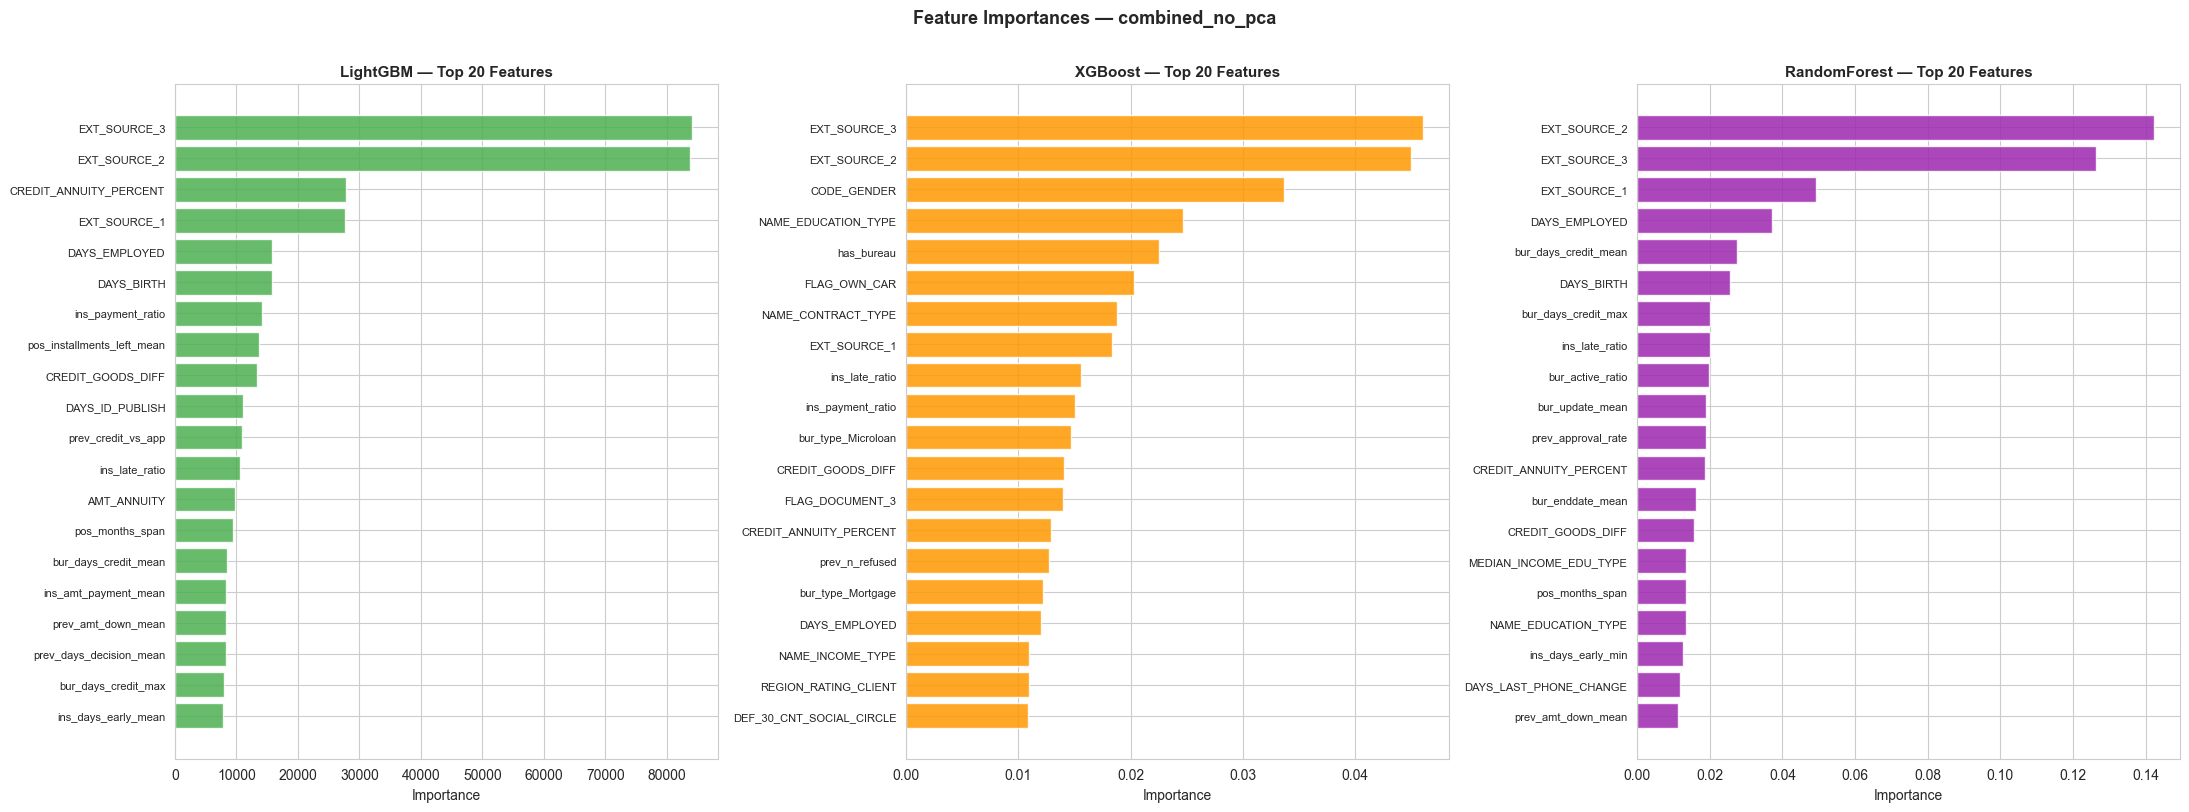

In [12]:
train_df_best, _, _ = datasets[best_dataset]
X_train_best, _ = xy(train_df_best)
feature_names = X_train_best.columns.tolist()

tree_models = {
    k: baseline_fitted[best_dataset][k]
    for k in ['LightGBM', 'XGBoost', 'RandomForest']
}

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, (model_name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.nlargest(20).sort_values()
    ax.barh(range(len(top)), top.values,
            color=MODEL_COLORS[model_name], edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([n[:35] for n in top.index], fontsize=8)
    ax.set_title(f'{model_name} — Top 20 Features', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle(f'Feature Importances — {best_dataset}', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.8 Lift Chart + KS Plot — Best Baseline Model

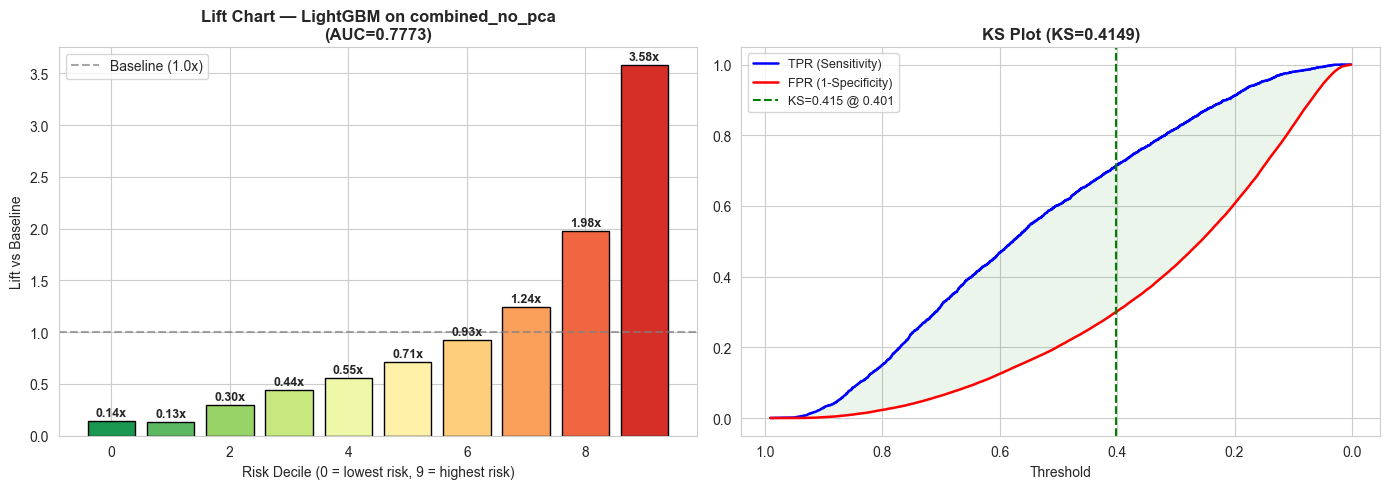

KS Statistic: 0.4149  (KS > 0.3 = production-ready scorecard)


In [13]:
best_model_name = max(
    baseline_results[best_dataset],
    key=lambda m: baseline_results[best_dataset][m]['AUC']
)
best_model  = baseline_fitted[best_dataset][best_model_name]
best_probas, y_val_best = baseline_probas[best_dataset]
y_proba_best = best_probas[best_model_name]

pred_df = pd.DataFrame({'pred': y_proba_best, 'actual': y_val_best.values})
pred_df['decile'] = pd.qcut(pred_df['pred'], q=10, labels=False, duplicates='drop')
lift = pred_df.groupby('decile')['actual'].mean() / y_val_best.mean()

fpr_k, tpr_k, thresholds_k = roc_curve(y_val_best, y_proba_best)
ks_stat = max(tpr_k - fpr_k)
ks_threshold = thresholds_k[np.argmax(tpr_k - fpr_k)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    range(len(lift)), lift.values,
    color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(lift))), edgecolor='black'
)
axes[0].axhline(1.0, color='grey', linestyle='--', alpha=0.7, label='Baseline (1.0x)')
for i, v in enumerate(lift.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Risk Decile (0 = lowest risk, 9 = highest risk)')
axes[0].set_ylabel('Lift vs Baseline')
axes[0].set_title(
    f'Lift Chart — {best_model_name} on {best_dataset}\n(AUC={baseline_results[best_dataset][best_model_name]["AUC"]:.4f})',
    fontweight='bold'
)
axes[0].legend()

axes[1].plot(thresholds_k, tpr_k, 'b-', linewidth=1.8, label='TPR (Sensitivity)')
axes[1].plot(thresholds_k, fpr_k, 'r-', linewidth=1.8, label='FPR (1-Specificity)')
axes[1].fill_between(thresholds_k, tpr_k, fpr_k, alpha=0.08, color='green')
axes[1].axvline(x=ks_threshold, color='green', linestyle='--',
                label=f'KS={ks_stat:.3f} @ {ks_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_title(f'KS Plot (KS={ks_stat:.4f})', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()
print(f'KS Statistic: {ks_stat:.4f}  (KS > 0.3 = production-ready scorecard)')

## 5. Hyperparameter Tuning (RandomizedSearchCV, n_iter=5)

In [14]:
param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
    },
    'LightGBM': {
        'num_leaves': [15, 31, 63], 
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 500],
        'min_child_samples': [20, 50, 100],
        'pos_weight': [1, 3, 5],
    },
    'XGBoost': {
        'max_depth': [3, 4, 6],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [200, 400],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.6, 0.8],
        'gamma': [0, 1, 5],
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', None],
        'bootstrap': [True, False]
    },
}

def make_base_estimators_for_tuning(scale_pos_weight=1.0):
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
        'LightGBM':           LGBMClassifier(random_state=SEED, verbose=-1, class_weight='balanced'),
        'XGBoost':            XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, scale_pos_weight=scale_pos_weight),
        'RandomForest':       RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
    }

In [15]:
if DO_HYPERTUNING:
    tuned_models    = {}
    tuned_results   = {}
    tuned_probas    = {}
    best_params_log = {}

    for dataset_name, (train_df, val_df, test_df) in datasets.items():
        X_train, y_train = xy(train_df)
        X_val,   y_val   = xy(val_df)
        
        # Calculate scale_pos_weight for XGBoost
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        tuned_models[dataset_name]    = {}
        best_params_log[dataset_name] = {}
        rows   = {}
        probas = {}
        
        base_estimators = make_base_estimators_for_tuning(scale_pos_weight=scale_pos_weight)

        for model_name, estimator in base_estimators.items():
            search = RandomizedSearchCV(
                estimator=estimator,
                param_distributions=param_grids[model_name],
                n_iter=10,
                scoring='recall',
                cv=3,
                random_state=SEED,
                n_jobs=1,
            )
            search.fit(X_train, y_train)
            best = search.best_estimator_
            tuned_models[dataset_name][model_name]    = best
            best_params_log[dataset_name][model_name] = search.best_params_
            rows[model_name]   = evaluate(best, X_val, y_val)
            probas[model_name] = best.predict_proba(X_val)[:, 1]
            print(f'  [{dataset_name}] {model_name:20s}  best Recall={rows[model_name]["Recall"]:.4f}  AUC={rows[model_name]["AUC"]:.4f}')

        tuned_results[dataset_name] = rows
        tuned_probas[dataset_name]  = (probas, y_val)

    print('\nTuning complete.')
else:
    print('Hyperparameter tuning DISABLED. Using baseline models for final evaluation.')
    tuned_models   = None
    tuned_results  = None
    tuned_probas   = None
    best_params_log = None


Hyperparameter tuning DISABLED. Using baseline models for final evaluation.


### 5.1 Best Hyperparameters Found

In [16]:
if DO_HYPERTUNING:
    for dataset_name, params_by_model in best_params_log.items():
        print(f'\n=== {dataset_name} ===')
        for model_name, params in params_by_model.items():
            print(f'  {model_name:20s}: {params}')
else:
    print('Hyperparameter tuning is disabled. Skipping best parameters display.')


Hyperparameter tuning is disabled. Skipping best parameters display.


### 5.2 Tuned Metrics Tables

In [17]:
if DO_HYPERTUNING:
    for dataset_name, rows in tuned_results.items():
        print(f'\n=== {dataset_name} (tuned) ===')
        df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
        display(df_res.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0).set_caption(f'{dataset_name} — tuned'))
else:
    print('Hyperparameter tuning is disabled. Showing baseline metrics instead.')
    for dataset_name, rows in baseline_results.items():
        print(f'\n=== {dataset_name} (baseline) ===')
        df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
        display(df_res.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0).set_caption(f'{dataset_name} — baseline (used for testing)'))


Hyperparameter tuning is disabled. Showing baseline metrics instead.

=== traditional_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5222,0.1291,0.2070,0.6809,0.6527
LightGBM,0.3360,0.1500,0.2074,0.7952,0.6464
XGBoost,0.3743,0.1355,0.1989,0.7596,0.6354
RandomForest,0.4229,0.1571,0.2291,0.7730,0.6797



=== traditional_no_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6722,0.1575,0.2552,0.6871,0.7466
LightGBM,0.6067,0.1871,0.2860,0.7584,0.7604
XGBoost,0.6091,0.1799,0.2778,0.7474,0.7502
RandomForest,0.6336,0.1745,0.2737,0.7318,0.7522



=== combined_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5890,0.1412,0.2278,0.6815,0.6892
LightGBM,0.3993,0.1666,0.2351,0.7928,0.6854
XGBoost,0.4148,0.1553,0.2260,0.7734,0.6658
RandomForest,0.4694,0.1682,0.2477,0.7726,0.7073



=== combined_no_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6967,0.1674,0.2699,0.6995,0.7667
LightGBM,0.6023,0.2047,0.3055,0.7816,0.7773
XGBoost,0.6048,0.1931,0.2928,0.7669,0.7648
RandomForest,0.6124,0.1834,0.2822,0.7516,0.7627


### 5.3 Baseline vs Tuned AUC — All Datasets

In [18]:
if DO_HYPERTUNING:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    for ax, dataset_name in zip(axes.flatten(), datasets.keys()):
        model_names = list(baseline_results[dataset_name].keys())
        base_aucs   = [baseline_results[dataset_name][m]['AUC']  for m in model_names]
        tuned_aucs  = [tuned_results[dataset_name][m]['AUC'] for m in model_names]

        x = np.arange(len(model_names))
        width = 0.35
        bars1 = ax.bar(x - width/2, base_aucs,  width, label='Baseline', color='#90caf9', edgecolor='black')
        bars2 = ax.bar(x + width/2, tuned_aucs, width, label='Tuned',    color='#1976d2', edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15, fontsize=9)
        ax.set_ylabel('AUC-ROC')
        ax.set_title(dataset_name, fontweight='bold', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_ylim(min(base_aucs + tuned_aucs) * 0.97, 1.0)

        for bar, v in zip(bars1, base_aucs):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=7)
        for bar, v in zip(bars2, tuned_aucs):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=7, fontweight='bold')

    plt.suptitle('Baseline vs Tuned AUC — All Datasets', fontweight='bold', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Hyperparameter tuning is disabled. Skipping comparison chart.')


Hyperparameter tuning is disabled. Skipping comparison chart.


### 5.4 ROC Curves — Tuned Models

In [19]:
if DO_HYPERTUNING:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    for ax, (dataset_name, (probas, y_val)) in zip(axes.flatten(), tuned_probas.items()):
        for model_name, proba in probas.items():
            fpr, tpr, _ = roc_curve(y_val, proba)
            auc = roc_auc_score(y_val, proba)
            ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=1.8,
                    label=f'{model_name} (AUC={auc:.4f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC — {dataset_name} (tuned)', fontweight='bold', fontsize=11)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('ROC Curves — Tuned Models', fontweight='bold', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Hyperparameter tuning is disabled. Skipping tuned ROC curves.')


Hyperparameter tuning is disabled. Skipping tuned ROC curves.


### 5.5 Tuned AUC Heatmap

In [20]:
if DO_HYPERTUNING:
    tuned_auc_matrix = pd.DataFrame(
        {ds: {m: tuned_results[ds][m]['AUC'] for m in tuned_results[ds]}
         for ds in tuned_results}
    ).T

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        tuned_auc_matrix.astype(float), annot=True, fmt='.4f',
        cmap='YlOrRd', ax=ax, linewidths=0.5,
        vmin=tuned_auc_matrix.values.min() * 0.99,
        vmax=tuned_auc_matrix.values.max() * 1.005
    )
    ax.set_title('Tuned AUC-ROC Heatmap — All Models x All Dataset Variants', fontweight='bold', fontsize=13)
    ax.set_xlabel('Model')
    ax.set_ylabel('Dataset Variant')
    plt.tight_layout()
    plt.show()
else:
    print('Hyperparameter tuning is disabled. Skipping tuned AUC heatmap.')


Hyperparameter tuning is disabled. Skipping tuned AUC heatmap.


## 6. Final Evaluation on Test Set (Best Tuned Models)

In [21]:
test_results = {}
test_probas  = {}

# Use tuned models if available, otherwise use baseline models
models_to_use = tuned_models if DO_HYPERTUNING else baseline_fitted
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'

for dataset_name, (train_df, val_df, test_df) in datasets.items():
    X_test, y_test = xy(test_df)
    rows   = {}
    probas = {}
    for model_name, model in models_to_use[dataset_name].items():
        rows[model_name]   = evaluate(model, X_test, y_test)
        probas[model_name] = model.predict_proba(X_test)[:, 1]
    test_results[dataset_name] = rows
    test_probas[dataset_name]  = (probas, y_test)

print(f'Test evaluation complete using {model_source} models.')


Test evaluation complete using Baseline models.


### 6.1 Test Set Metrics Tables

In [22]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
for dataset_name, rows in test_results.items():
    print(f'\n=== {dataset_name} — Test Set ({model_source} Models) ===')
    df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
    display(df_res.style.format('{:.4f}').background_gradient(cmap='Oranges', axis=0).set_caption(f'{dataset_name} — test ({model_source})'))



=== traditional_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6446,0.1491,0.2421,0.6734,0.7135
LightGBM,0.5265,0.1602,0.2456,0.7382,0.6996
XGBoost,0.5171,0.1535,0.2367,0.7301,0.6874
RandomForest,0.5787,0.1595,0.2501,0.7190,0.7165



=== traditional_no_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6786,0.1595,0.2583,0.6845,0.7436
LightGBM,0.6004,0.1862,0.2843,0.7553,0.7549
XGBoost,0.6018,0.1789,0.2758,0.7442,0.7481
RandomForest,0.6253,0.1722,0.2701,0.7264,0.7457



=== combined_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5892,0.1475,0.2359,0.6910,0.7005
LightGBM,0.3273,0.1646,0.2191,0.8111,0.6626
XGBoost,0.3666,0.1479,0.2107,0.7777,0.6499
RandomForest,0.4430,0.1688,0.2445,0.7784,0.6982



=== combined_no_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6960,0.1684,0.2712,0.6972,0.7641
LightGBM,0.5932,0.2018,0.3012,0.7772,0.7728
XGBoost,0.5972,0.1924,0.2910,0.7644,0.7609
RandomForest,0.6069,0.1820,0.2800,0.7473,0.7532


### 6.2 Test ROC Curves

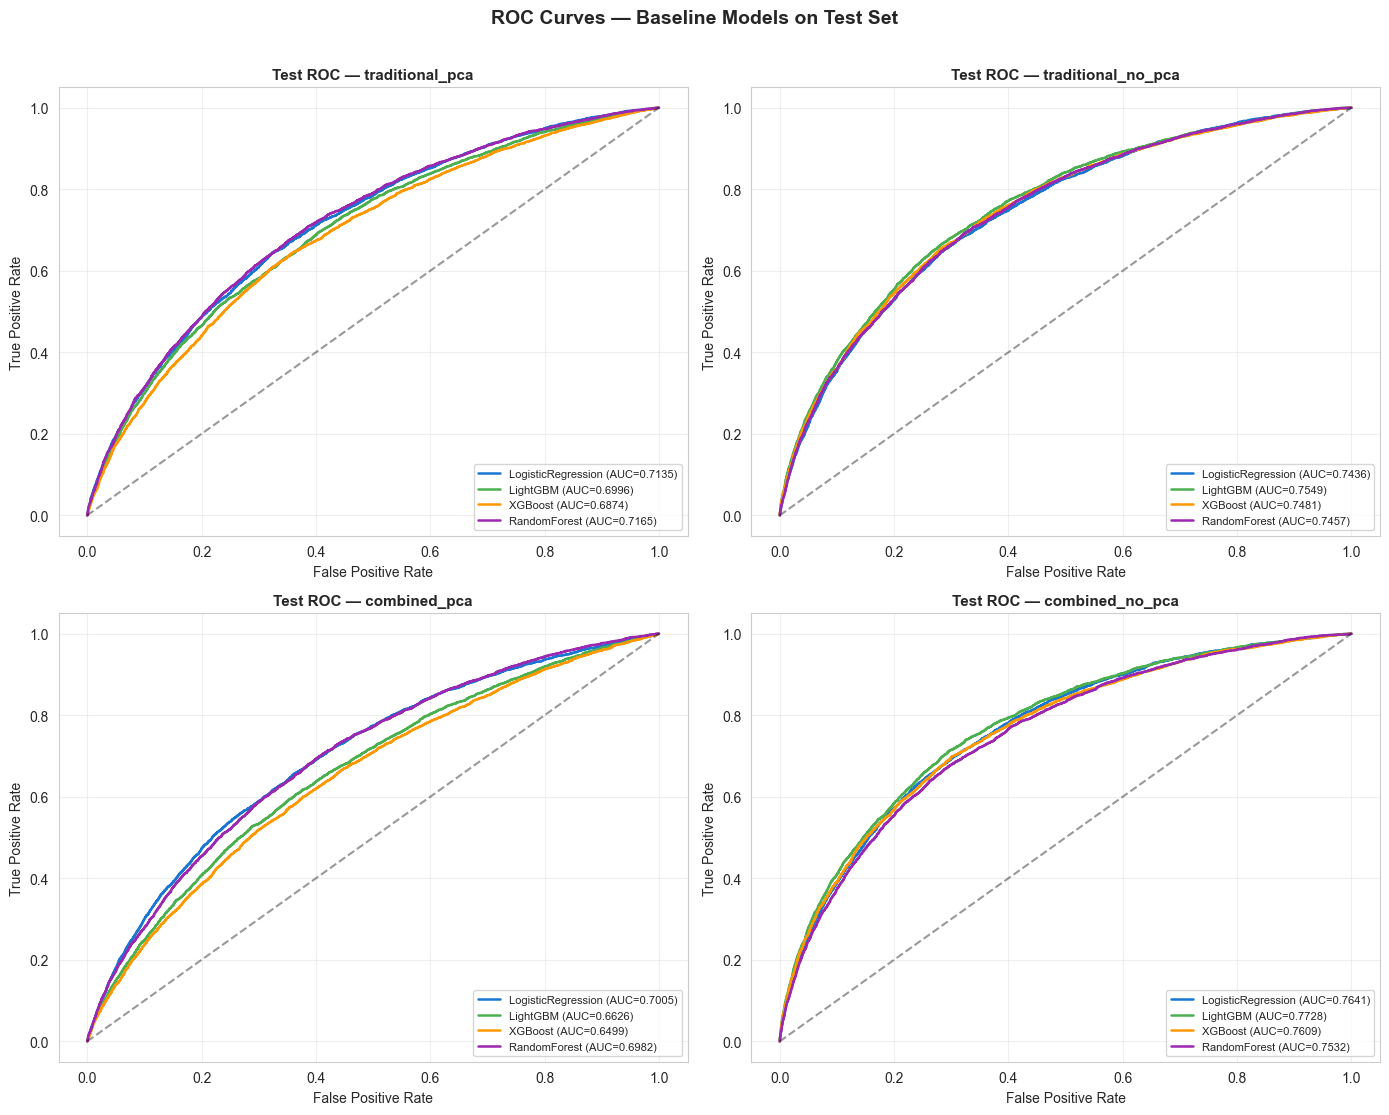

In [23]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (dataset_name, (probas, y_test)) in zip(axes.flatten(), test_probas.items()):
    for model_name, proba in probas.items():
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=1.8,
                label=f'{model_name} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Test ROC — {dataset_name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'ROC Curves — {model_source} Models on Test Set', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 6.3 Final Test AUC Heatmap

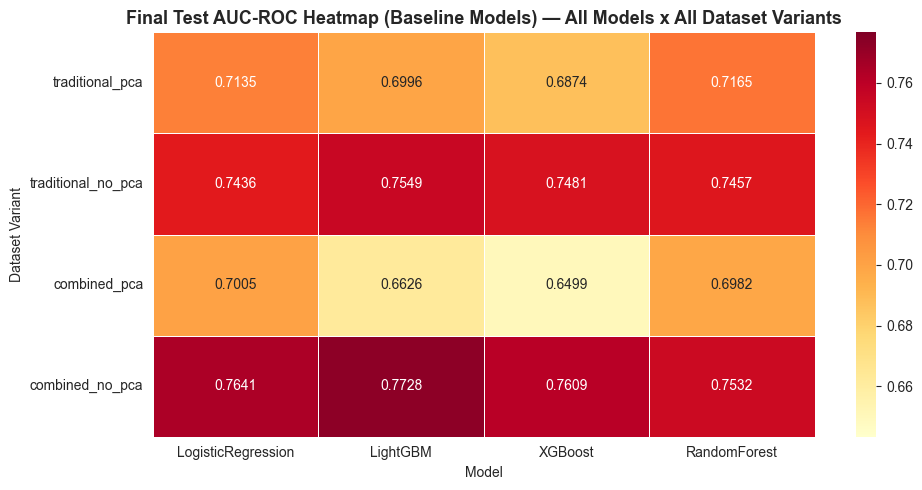

In [24]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
test_auc_matrix = pd.DataFrame(
    {ds: {m: test_results[ds][m]['AUC'] for m in test_results[ds]}
     for ds in test_results}
).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    test_auc_matrix.astype(float), annot=True, fmt='.4f',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    vmin=test_auc_matrix.values.min() * 0.99,
    vmax=test_auc_matrix.values.max() * 1.005
)
ax.set_title(f'Final Test AUC-ROC Heatmap ({model_source} Models) — All Models x All Dataset Variants', fontweight='bold', fontsize=13)
ax.set_xlabel('Model')
ax.set_ylabel('Dataset Variant')
plt.tight_layout()
plt.show()


### 6.4 Overall Best Model Summary

In [25]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
summary_rows = []
for ds, rows in test_results.items():
    for model_name, metrics in rows.items():
        summary_rows.append({'Dataset': ds, 'Model': model_name, **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values('AUC', ascending=False).reset_index(drop=True)
summary_df[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']] = \
    summary_df[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']].round(4)

print(f'=== TOP 10 MODEL-DATASET COMBINATIONS BY TEST AUC ({model_source} Models) ===')
display(summary_df.head(10).style.background_gradient(subset=['AUC'], cmap='YlOrRd'))

best_row = summary_df.iloc[0]
print(f'\nOverall Best: {best_row["Model"]} on {best_row["Dataset"]}')
print(f'  AUC={best_row["AUC"]:.4f}  F1={best_row["F1"]:.4f}  Recall={best_row["Recall"]:.4f}  Precision={best_row["Precision"]:.4f}')
print(f'  Models used: {model_source}')


=== TOP 10 MODEL-DATASET COMBINATIONS BY TEST AUC (Baseline Models) ===


,Dataset,Model,Recall,Precision,F1,Accuracy,AUC
0,combined_no_pca,LightGBM,0.593200,0.201800,0.301200,0.777200,0.772800
1,combined_no_pca,LogisticRegression,0.696000,0.168400,0.271200,0.697200,0.764100
2,combined_no_pca,XGBoost,0.597200,0.192400,0.291000,0.764400,0.760900
3,traditional_no_pca,LightGBM,0.600400,0.186200,0.284300,0.755300,0.754900
4,combined_no_pca,RandomForest,0.606900,0.182000,0.280000,0.747300,0.753200
5,traditional_no_pca,XGBoost,0.601800,0.178900,0.275800,0.744200,0.748100
6,traditional_no_pca,RandomForest,0.625300,0.172200,0.270100,0.726400,0.745700
7,traditional_no_pca,LogisticRegression,0.678600,0.159500,0.258300,0.684500,0.743600
8,traditional_pca,RandomForest,0.578700,0.159500,0.250100,0.719000,0.716500
9,traditional_pca,LogisticRegression,0.644600,0.149100,0.242100,0.673400,0.713500



Overall Best: LightGBM on combined_no_pca
  AUC=0.7728  F1=0.3012  Recall=0.5932  Precision=0.2018
  Models used: Baseline
